In [1]:
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "--target", "/usr/local/lib/python3.12/dist-packages",
                "--upgrade", "--force-reinstall", "--no-deps",
                "numpy>=2.0"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "kagglehub", "torchmetrics[image]"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "--no-deps", "facenet-pytorch"], check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', '--no-deps', 'facenet-pytorch'], returncode=0)

In [2]:
import kagglehub

CELEBA_ROOT = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(CELEBA_ROOT)

Using Colab cache for faster access to the 'celeba-dataset' dataset.
/kaggle/input/celeba-dataset


In [3]:
import os
import math
import json
import random
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split


from facenet_pytorch import MTCNN

from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

## Конфиг

In [4]:
@dataclass
class Config:
    data_root: str = f"{CELEBA_ROOT}"
    images_dir_name: str = "img_align_celeba/img_align_celeba"
    attr_path: str = f"{CELEBA_ROOT}/list_attr_celeba.csv"
    cropped_dir: str = "/kaggle/working/celeba_cropped"
    checkpoints_dir: str = "/kaggle/working/checkpoints"
    samples_dir: str = "/kaggle/working/samples"

    image_size: int = 64
    face_margin: float = 0.20
    max_preprocess_images: int | None = 20_000
    mtcnn_image_size: int = 160
    mtcnn_min_face_size: int = 40

    batch_size: int = 128
    num_workers: int = 0
    z_dim: int = 128
    g_features: int = 64
    d_features: int = 64
    num_epochs: int = 10
    lr: float = 2e-4
    beta1: float = 0.5
    beta2: float = 0.999

    num_classes: int = 2
    label_emb_dim: int = 16

    wgan_lr: float = 1e-4
    wgan_beta1: float = 0.0
    wgan_beta2: float = 0.9
    lambda_gp: float = 10.0
    n_critic: int = 5

    eval_num_images: int = 2_000
    seed: int = 42
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()

Path(cfg.cropped_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.checkpoints_dir).mkdir(parents=True, exist_ok=True)
Path(cfg.samples_dir).mkdir(parents=True, exist_ok=True)

print(asdict(cfg))

{'data_root': '/kaggle/input/celeba-dataset', 'images_dir_name': 'img_align_celeba/img_align_celeba', 'attr_path': '/kaggle/input/celeba-dataset/list_attr_celeba.csv', 'cropped_dir': '/kaggle/working/celeba_cropped', 'checkpoints_dir': '/kaggle/working/checkpoints', 'samples_dir': '/kaggle/working/samples', 'image_size': 64, 'face_margin': 0.2, 'max_preprocess_images': 20000, 'mtcnn_image_size': 160, 'mtcnn_min_face_size': 40, 'batch_size': 128, 'num_workers': 0, 'z_dim': 128, 'g_features': 64, 'd_features': 64, 'num_epochs': 10, 'lr': 0.0002, 'beta1': 0.5, 'beta2': 0.999, 'num_classes': 2, 'label_emb_dim': 16, 'wgan_lr': 0.0001, 'wgan_beta1': 0.0, 'wgan_beta2': 0.9, 'lambda_gp': 10.0, 'n_critic': 5, 'eval_num_images': 2000, 'seed': 42, 'device': 'cuda'}


In [5]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(cfg.seed)

In [6]:
def load_celeba_attributes(attr_path: str) -> pd.DataFrame:
    attr_path = Path(attr_path)
    if attr_path.suffix.lower() == ".csv":
        df = pd.read_csv(attr_path)
        return df

    with open(attr_path, "r", encoding="utf-8") as f:
        lines = [line.strip() for line in f.readlines() if line.strip()]

    n = int(lines[0])
    columns = lines[1].split()
    rows = []
    for line in lines[2:2+n]:
        parts = line.split()
        image_id = parts[0]
        values = list(map(int, parts[1:]))
        row = {"image_id": image_id}
        row.update({col: val for col, val in zip(columns, values)})
        rows.append(row)

    df = pd.DataFrame(rows)
    return df

attrs_df = load_celeba_attributes(cfg.attr_path)
attrs_df.head()

,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


In [7]:
attrs_df["Male_bin"] = (attrs_df["Male"] == 1).astype(int)

print(attrs_df.shape)
print(attrs_df["Male_bin"].value_counts())

(202599, 42)
Male_bin
0    118165
1     84434
Name: count, dtype: int64


In [8]:
mtcnn = MTCNN(
    image_size=cfg.mtcnn_image_size,
    margin=0,
    min_face_size=cfg.mtcnn_min_face_size,
    select_largest=True,
    post_process=False,
    device=cfg.device,
)
print(f"MTCNN ready on {cfg.device}")


MTCNN ready on cuda


In [9]:
def expand_box(box, width, height, margin=0.2):
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    x1 = max(0, int(x1 - bw * margin))
    y1 = max(0, int(y1 - bh * margin))
    x2 = min(width, int(x2 + bw * margin))
    y2 = min(height, int(y2 + bh * margin))
    return x1, y1, x2, y2


def _center_crop_resize(image: Image.Image, out_size: int) -> Image.Image:
    w, h = image.size
    s = min(w, h)
    left, top = (w - s) // 2, (h - s) // 2
    return image.crop((left, top, left + s, top + s)).resize((out_size, out_size), Image.BICUBIC)


def crop_face(image: Image.Image, boxes, out_size: int, margin: float) -> Image.Image:
    if boxes is not None and len(boxes) > 0:
        x1, y1, x2, y2 = expand_box(boxes[0], image.width, image.height, margin)
        face = image.crop((x1, y1, x2, y2)).convert("RGB")
        return face.resize((out_size, out_size), Image.BICUBIC)
    return _center_crop_resize(image.convert("RGB"), out_size)


In [10]:
def preprocess_celeba_faces(cfg: Config, attrs_df: pd.DataFrame,
                             batch_size: int = 64) -> pd.DataFrame:
    img_dir = Path(cfg.data_root) / cfg.images_dir_name
    out_dir = Path(cfg.cropped_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    all_rows = list(attrs_df.itertuples(index=False))
    if cfg.max_preprocess_images is not None:
        all_rows = all_rows[:cfg.max_preprocess_images]

    rows, to_do = [], []
    for row in all_rows:
        dst = out_dir / row.image_id
        if dst.exists():
            rows.append({"image_id": row.image_id, "path": str(dst), "Male_bin": int(row.Male_bin)})
        else:
            to_do.append(row)

    print(f"Already cached: {len(rows)}, to process: {len(to_do)}")

    for start in tqdm(range(0, len(to_do), batch_size), desc="Preprocessing"):
        batch = to_do[start : start + batch_size]
        images, valid = [], []
        for row in batch:
            try:
                images.append(Image.open(img_dir / row.image_id).convert("RGB"))
                valid.append(row)
            except Exception:
                continue

        if not images:
            continue

        try:
            boxes_batch, _ = mtcnn.detect(images)
        except Exception:
            boxes_batch = [None] * len(images)

        for img, row, boxes in zip(images, valid, boxes_batch):
            face = crop_face(img, boxes, cfg.image_size, cfg.face_margin)
            dst = out_dir / row.image_id
            face.save(dst, quality=95)
            rows.append({"image_id": row.image_id, "path": str(dst), "Male_bin": int(row.Male_bin)})

    result_df = pd.DataFrame(rows)
    print(f"Total saved: {len(result_df)}")
    return result_df

cropped_meta_path = Path(cfg.cropped_dir) / "cropped_meta.csv"

def _load_or_build_meta(path: Path) -> pd.DataFrame:
    if path.exists():
        try:
            df = pd.read_csv(path)
            if not df.empty:
                print(f"Loaded existing cropped metadata: {df.shape}")
                return df
        except pd.errors.EmptyDataError:
            pass
        path.unlink()
    df = preprocess_celeba_faces(cfg, attrs_df)
    df.to_csv(path, index=False)
    print(f"Saved cropped metadata: {df.shape}")
    return df

cropped_df = _load_or_build_meta(cropped_meta_path)

cropped_df.head()

Already cached: 0, to process: 20000


Preprocessing:   0%|          | 0/313 [00:00<?, ?it/s]

Total saved: 20000
Saved cropped metadata: (20000, 3)


,image_id,path,Male_bin
0,000001.jpg,/kaggle/working/celeba_cropped/000001.jpg,0
1,000002.jpg,/kaggle/working/celeba_cropped/000002.jpg,0
2,000003.jpg,/kaggle/working/celeba_cropped/000003.jpg,1
3,000004.jpg,/kaggle/working/celeba_cropped/000004.jpg,0
4,000005.jpg,/kaggle/working/celeba_cropped/000005.jpg,0


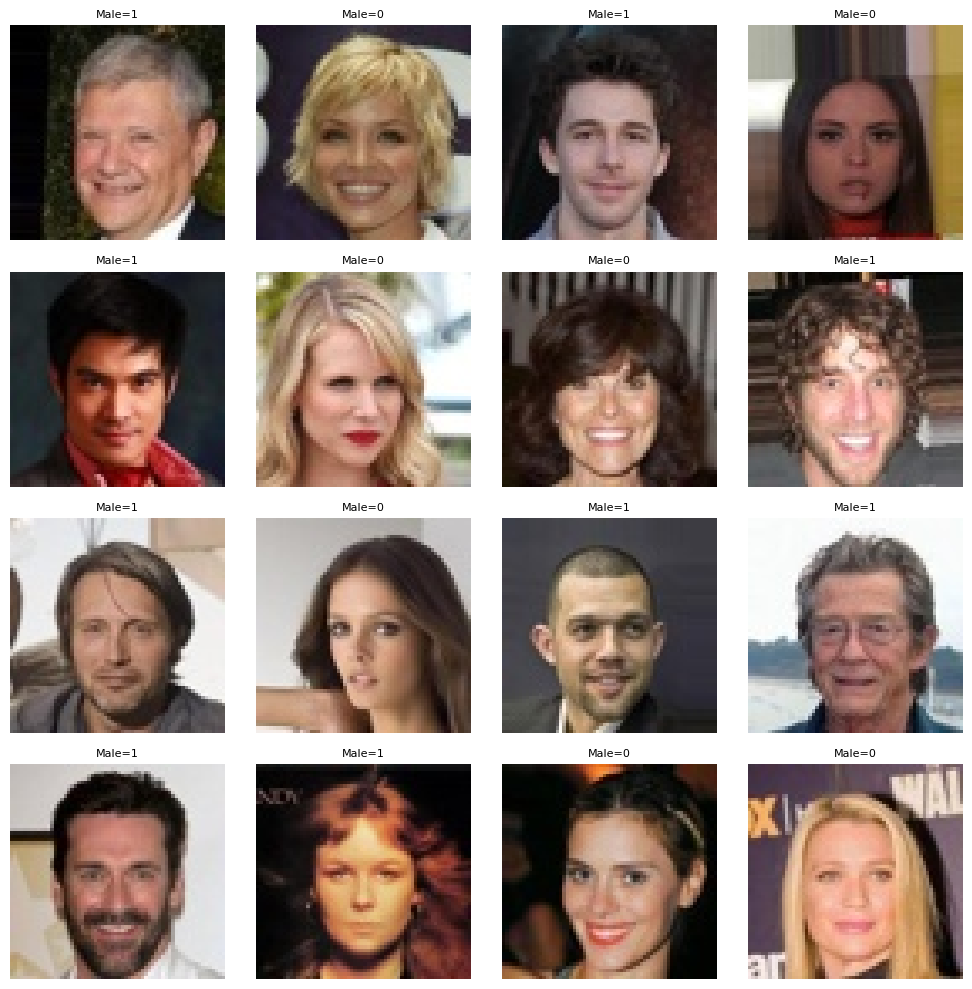

In [11]:
def show_random_crops(meta_df: pd.DataFrame, n: int = 16):
    sample_df = meta_df.sample(min(n, len(meta_df)), random_state=cfg.seed)
    cols = 4
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    for ax, row in zip(axes.flat, sample_df.itertuples(index=False)):
        ax.imshow(Image.open(row.path).convert("RGB"))
        ax.set_title(f"Male={row.Male_bin}", fontsize=8)
        ax.axis("off")
    for ax in axes.flat[len(sample_df):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

show_random_crops(cropped_df, n=16)


## Train / val split

In [12]:
train_df, val_df = train_test_split(
    cropped_df,
    test_size=0.1,
    random_state=cfg.seed,
    stratify=cropped_df["Male_bin"],
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(train_df.shape, val_df.shape)
print("Train Male ratio:", train_df["Male_bin"].mean())
print("Val   Male ratio:", val_df["Male_bin"].mean())

(18000, 3) (2000, 3)
Train Male ratio: 0.42155555555555557
Val   Male ratio: 0.4215


## Dataset и DataLoader

In [13]:
def _pil_to_tensor(pic: Image.Image) -> torch.Tensor:
    w, h = pic.size
    bands = len(pic.getbands())
    return (
        torch.frombuffer(bytearray(pic.tobytes()), dtype=torch.uint8)
        .reshape(h, w, bands)
        .permute(2, 0, 1)
        .clone()
    )


def _tensor_to_pil(t: torch.Tensor) -> Image.Image:
    t = t.clamp(0, 1).mul(255).byte().permute(1, 2, 0)
    h, w, c = t.shape
    mode = "RGB" if c == 3 else "L"
    return Image.frombuffer(mode, (w, h), bytes(t.reshape(-1).tolist()))


def denorm(x: torch.Tensor) -> torch.Tensor:
    return ((x + 1) / 2).clamp(0, 1)


def show_batch(images: torch.Tensor, nrow: int = 8, title: str = ""):
    images = denorm(images.detach().cpu())
    grid = utils.make_grid(images, nrow=nrow, padding=2)
    pil_grid = _tensor_to_pil(grid)
    plt.figure(figsize=(12, 12))
    plt.imshow(pil_grid)
    plt.title(title)
    plt.axis("off")
    plt.show()


Loading images:   0%|          | 0/18000 [00:00<?, ?it/s]

Loading images:   0%|          | 0/2000 [00:00<?, ?it/s]

torch.Size([128, 3, 64, 64]) torch.Size([128])


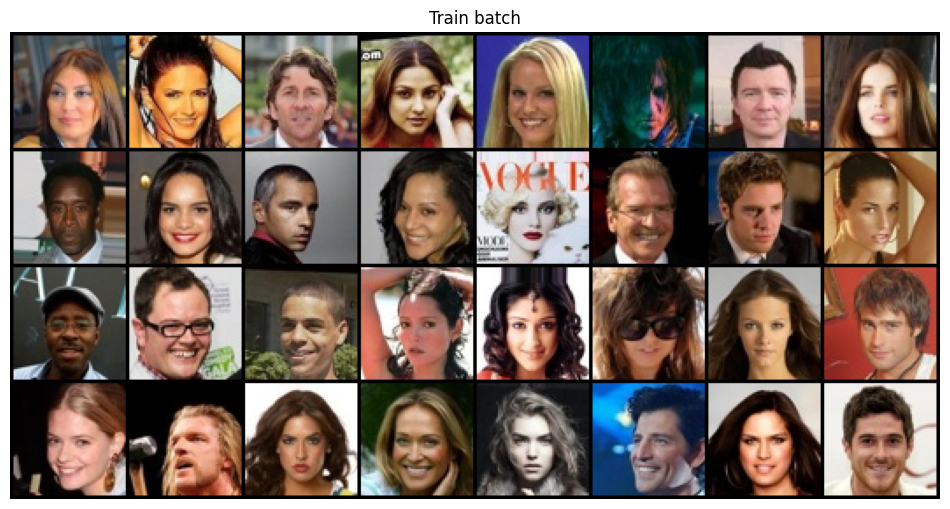

In [14]:
class CelebACroppedDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, image_size: int = 64):
        self.meta_df = meta_df.reset_index(drop=True)
        self._norm = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
        self._tensors = []
        for _, row in tqdm(self.meta_df.iterrows(), total=len(self.meta_df),
                           desc="Loading images", leave=False):
            img = Image.open(row["path"]).convert("RGB").resize((image_size, image_size), Image.BICUBIC)
            self._tensors.append(_pil_to_tensor(img))

    def __len__(self) -> int:
        return len(self.meta_df)

    def __getitem__(self, idx: int):
        image = self._norm(self._tensors[idx].float() / 255.0)
        label = int(self.meta_df.iloc[idx]["Male_bin"])
        return image, label


train_ds = CelebACroppedDataset(train_df, image_size=cfg.image_size)
val_ds   = CelebACroppedDataset(val_df,   image_size=cfg.image_size)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=0, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=0, pin_memory=True, drop_last=False)

batch = next(iter(train_loader))
print(batch[0].shape, batch[1].shape)

images, labels = next(iter(train_loader))
show_batch(images[:32], nrow=8, title="Train batch")


In [15]:
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1 or classname.find("Linear") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if getattr(m, "bias", None) is not None:
            nn.init.constant_(m.bias.data, 0.0)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)

In [16]:
class Generator(nn.Module):
    def __init__(self, z_dim=128, base_channels=64, img_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, base_channels * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base_channels * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 2, base_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels, img_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, base_channels=64, img_channels=3):
        super().__init__()
        SN = nn.utils.spectral_norm
        self.net = nn.Sequential(
            SN(nn.Conv2d(img_channels, base_channels, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            SN(nn.Conv2d(base_channels, base_channels * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),

            SN(nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2, inplace=True),

            SN(nn.Conv2d(base_channels * 4, base_channels * 8, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(base_channels * 8),
            nn.LeakyReLU(0.2, inplace=True),

            SN(nn.Conv2d(base_channels * 8, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [17]:
G = Generator(z_dim=cfg.z_dim, base_channels=cfg.g_features).to(cfg.device)
D = Discriminator(base_channels=cfg.d_features).to(cfg.device)

G.apply(weights_init_normal)
D.apply(weights_init_normal)

criterion_bce = nn.BCEWithLogitsLoss()

opt_G = torch.optim.Adam(G.parameters(), lr=cfg.lr, betas=(cfg.beta1, cfg.beta2))
opt_D = torch.optim.Adam(D.parameters(), lr=cfg.lr, betas=(cfg.beta1, cfg.beta2))

fixed_noise = torch.randn(64, cfg.z_dim, device=cfg.device)

print(G.__class__.__name__, D.__class__.__name__)

Generator Discriminator


In [18]:
@torch.no_grad()
def save_generator_samples(generator, noise, path, nrow=8):
    generator.eval()
    fake = generator(noise)
    grid = utils.make_grid(denorm(fake.cpu()), nrow=nrow, padding=2)
    _tensor_to_pil(grid).save(path)
    generator.train()

def train_unconditional_gan(
    G, D, train_loader, cfg: Config, epochs: int = 20
):
    history = {
        "g_loss": [],
        "d_loss": [],
    }

    real_label = 0.9
    fake_label = 0.0

    try:
      for epoch in range(1, epochs + 1):
        loop = tqdm(train_loader, desc=f"[GAN] Epoch {epoch}/{epochs}")
        g_running = 0.0
        d_running = 0.0
        n_batches = 0

        for real_imgs, _ in loop:
            real_imgs = real_imgs.to(cfg.device)
            batch_size = real_imgs.size(0)

            opt_D.zero_grad()

            y_real = torch.full((batch_size,), real_label, device=cfg.device)
            y_fake = torch.full((batch_size,), fake_label, device=cfg.device)

            out_real = D(real_imgs)
            d_loss_real = criterion_bce(out_real, y_real)

            z = torch.randn(batch_size, cfg.z_dim, device=cfg.device)
            fake_imgs = G(z)
            out_fake = D(fake_imgs.detach())
            d_loss_fake = criterion_bce(out_fake, y_fake)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            opt_D.step()

            opt_G.zero_grad()
            out_fake_for_g = D(fake_imgs)
            g_loss = criterion_bce(out_fake_for_g, y_real)
            g_loss.backward()
            opt_G.step()

            g_running += g_loss.item()
            d_running += d_loss.item()
            n_batches += 1

            loop.set_postfix({
                "g_loss": f"{g_loss.item():.4f}",
                "d_loss": f"{d_loss.item():.4f}",
            })

        history["g_loss"].append(g_running / n_batches)
        history["d_loss"].append(d_running / n_batches)

        sample_path = Path(cfg.samples_dir) / f"gan_epoch_{epoch:03d}.png"
        save_generator_samples(G, fixed_noise, sample_path)

        ckpt_path = Path(cfg.checkpoints_dir) / f"gan_epoch_{epoch:03d}.pt"
        torch.save({
            "G": G.state_dict(),
            "D": D.state_dict(),
            "opt_G": opt_G.state_dict(),
            "opt_D": opt_D.state_dict(),
            "history": history,
            "cfg": asdict(cfg),
        }, ckpt_path)

    except KeyboardInterrupt:
        print(f"GAN interrupted after epoch {len(history['g_loss'])}")
    return history

history_gan = train_unconditional_gan(G, D, train_loader, cfg, epochs=cfg.num_epochs)

[GAN] Epoch 1/10:   0%|          | 0/140 [00:00<?, ?it/s]

[GAN] Epoch 2/10:   0%|          | 0/140 [00:00<?, ?it/s]

[GAN] Epoch 3/10:   0%|          | 0/140 [00:00<?, ?it/s]

[GAN] Epoch 4/10:   0%|          | 0/140 [00:00<?, ?it/s]

[GAN] Epoch 5/10:   0%|          | 0/140 [00:00<?, ?it/s]

[GAN] Epoch 6/10:   0%|          | 0/140 [00:00<?, ?it/s]

[GAN] Epoch 7/10:   0%|          | 0/140 [00:00<?, ?it/s]

[GAN] Epoch 8/10:   0%|          | 0/140 [00:00<?, ?it/s]

[GAN] Epoch 9/10:   0%|          | 0/140 [00:00<?, ?it/s]

[GAN] Epoch 10/10:   0%|          | 0/140 [00:00<?, ?it/s]

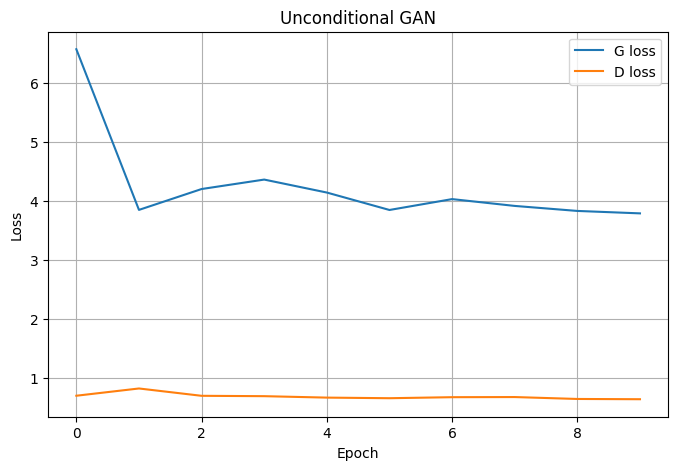

In [19]:
def plot_losses(history: dict[str, list[float]], title: str = "Loss curves"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["g_loss"], label="G loss")
    plt.plot(history["d_loss"], label="D loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_losses(history_gan, title="Unconditional GAN")

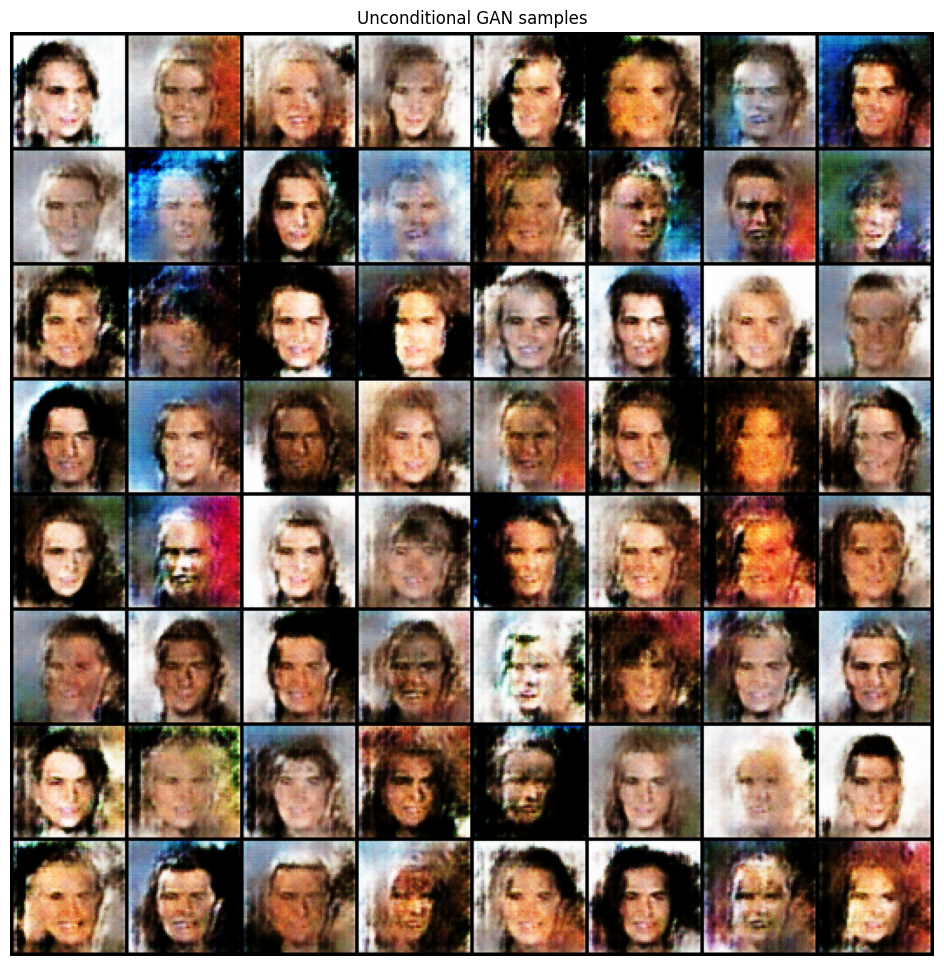

In [20]:
show_batch(G(fixed_noise).detach(), nrow=8, title="Unconditional GAN samples")

In [21]:
def to_uint8_batch(x: torch.Tensor) -> torch.Tensor:
    x = denorm(x)
    x = (x * 255.0).clamp(0, 255).to(torch.uint8)
    return x

@torch.no_grad()
def compute_fid_is_unconditional(
    generator: nn.Module,
    val_loader: DataLoader,
    z_dim: int,
    device: str,
    num_images: int = 5000,
):
    generator.eval()

    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    inc = InceptionScore(normalize=False).to(device)

    real_seen = 0
    for real_imgs, _ in tqdm(val_loader, desc="FID/IS real"):
        real_imgs = real_imgs.to(device)
        real_uint8 = to_uint8_batch(real_imgs)
        fid.update(real_uint8, real=True)
        real_seen += real_imgs.size(0)
        if real_seen >= num_images:
            break

    fake_seen = 0
    batch_size = val_loader.batch_size or 64
    while fake_seen < num_images:
        cur_bs = min(batch_size, num_images - fake_seen)
        z = torch.randn(cur_bs, z_dim, device=device)
        fake_imgs = generator(z)
        fake_uint8 = to_uint8_batch(fake_imgs)
        fid.update(fake_uint8, real=False)
        inc.update(fake_uint8)
        fake_seen += cur_bs

    fid_value = fid.compute().item()
    is_mean, is_std = inc.compute()
    return {
        "FID": float(fid_value),
        "IS_mean": float(is_mean.item()),
        "IS_std": float(is_std.item()),
    }

metrics_gan = compute_fid_is_unconditional(G, val_loader, cfg.z_dim, cfg.device, cfg.eval_num_images)
metrics_gan

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 367MB/s]
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


FID/IS real:   0%|          | 0/16 [00:00<?, ?it/s]

{'FID': 161.61659240722656,
 'IS_mean': 2.105499029159546,
 'IS_std': 0.0832914412021637}

In [22]:
class ConditionalGenerator(nn.Module):
    def __init__(self, z_dim=128, num_classes=2, label_emb_dim=16, base_channels=64, img_channels=3):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, label_emb_dim)
        input_dim = z_dim + label_emb_dim

        self.net = nn.Sequential(
            nn.ConvTranspose2d(input_dim, base_channels * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(base_channels * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels * 2, base_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(True),

            nn.ConvTranspose2d(base_channels, img_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z, y):
        y_emb = self.label_emb(y)
        zy = torch.cat([z, y_emb], dim=1)
        zy = zy.view(zy.size(0), zy.size(1), 1, 1)
        return self.net(zy)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, num_classes=2, image_size=64, base_channels=64, img_channels=3):
        super().__init__()
        self.image_size = image_size
        self.label_emb = nn.Embedding(num_classes, image_size * image_size)

        in_channels = img_channels + 1
        SN = nn.utils.spectral_norm

        self.net = nn.Sequential(
            SN(nn.Conv2d(in_channels, base_channels, 4, 2, 1, bias=False)),
            nn.LeakyReLU(0.2, inplace=True),

            SN(nn.Conv2d(base_channels, base_channels * 2, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),

            SN(nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2, inplace=True),

            SN(nn.Conv2d(base_channels * 4, base_channels * 8, 4, 2, 1, bias=False)),
            nn.BatchNorm2d(base_channels * 8),
            nn.LeakyReLU(0.2, inplace=True),

            SN(nn.Conv2d(base_channels * 8, 1, 4, 1, 0, bias=False)),
        )

    def forward(self, x, y):
        y_map = self.label_emb(y).view(y.size(0), 1, self.image_size, self.image_size)
        inp = torch.cat([x, y_map], dim=1)
        return self.net(inp).view(-1)

In [23]:
cG = ConditionalGenerator(
    z_dim=cfg.z_dim,
    num_classes=cfg.num_classes,
    label_emb_dim=cfg.label_emb_dim,
    base_channels=cfg.g_features,
).to(cfg.device)

cD = ConditionalDiscriminator(
    num_classes=cfg.num_classes,
    image_size=cfg.image_size,
    base_channels=cfg.d_features,
).to(cfg.device)

cG.apply(weights_init_normal)
cD.apply(weights_init_normal)

opt_cG = torch.optim.Adam(cG.parameters(), lr=cfg.lr, betas=(cfg.beta1, cfg.beta2))
opt_cD = torch.optim.Adam(cD.parameters(), lr=cfg.lr, betas=(cfg.beta1, cfg.beta2))

fixed_noise_c = torch.randn(16, cfg.z_dim, device=cfg.device)
fixed_labels_0 = torch.zeros(16, dtype=torch.long, device=cfg.device)
fixed_labels_1 = torch.ones(16, dtype=torch.long, device=cfg.device)

In [24]:
@torch.no_grad()
def save_conditional_samples(generator, noise, labels, path, nrow=4):
    generator.eval()
    fake = generator(noise, labels)
    grid = utils.make_grid(denorm(fake.cpu()), nrow=nrow, padding=2)
    _tensor_to_pil(grid).save(path)
    generator.train()

def train_conditional_gan(
    G, D, train_loader, cfg: Config, epochs: int = 20
):
    history = {
        "g_loss": [],
        "d_loss": [],
    }

    real_label = 0.9
    fake_label = 0.0

    try:
      for epoch in range(1, epochs + 1):
        loop = tqdm(train_loader, desc=f"[cGAN] Epoch {epoch}/{epochs}")
        g_running = 0.0
        d_running = 0.0
        n_batches = 0

        for real_imgs, labels in loop:
            real_imgs = real_imgs.to(cfg.device)
            labels = labels.to(cfg.device).long()
            batch_size = real_imgs.size(0)

            opt_cD.zero_grad()

            y_real = torch.full((batch_size,), real_label, device=cfg.device)
            y_fake = torch.full((batch_size,), fake_label, device=cfg.device)

            out_real = D(real_imgs, labels)
            d_loss_real = criterion_bce(out_real, y_real)

            z = torch.randn(batch_size, cfg.z_dim, device=cfg.device)
            fake_imgs = G(z, labels)
            out_fake = D(fake_imgs.detach(), labels)
            d_loss_fake = criterion_bce(out_fake, y_fake)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            opt_cD.step()

            opt_cG.zero_grad()
            out_fake_for_g = D(fake_imgs, labels)
            g_loss = criterion_bce(out_fake_for_g, y_real)
            g_loss.backward()
            opt_cG.step()

            g_running += g_loss.item()
            d_running += d_loss.item()
            n_batches += 1

            loop.set_postfix({
                "g_loss": f"{g_loss.item():.4f}",
                "d_loss": f"{d_loss.item():.4f}",
            })

        history["g_loss"].append(g_running / n_batches)
        history["d_loss"].append(d_running / n_batches)

        sample_path0 = Path(cfg.samples_dir) / f"cgan_epoch_{epoch:03d}_label0.png"
        sample_path1 = Path(cfg.samples_dir) / f"cgan_epoch_{epoch:03d}_label1.png"
        save_conditional_samples(G, fixed_noise_c, fixed_labels_0, sample_path0)
        save_conditional_samples(G, fixed_noise_c, fixed_labels_1, sample_path1)

        ckpt_path = Path(cfg.checkpoints_dir) / f"cgan_epoch_{epoch:03d}.pt"
        torch.save({
            "G": G.state_dict(),
            "D": D.state_dict(),
            "opt_G": opt_cG.state_dict(),
            "opt_D": opt_cD.state_dict(),
            "history": history,
            "cfg": asdict(cfg),
        }, ckpt_path)

    except KeyboardInterrupt:
        print(f"cGAN interrupted after epoch {len(history['g_loss'])}")
    return history

history_cgan = train_conditional_gan(cG, cD, train_loader, cfg, epochs=cfg.num_epochs)

[cGAN] Epoch 1/10:   0%|          | 0/140 [00:00<?, ?it/s]

[cGAN] Epoch 2/10:   0%|          | 0/140 [00:00<?, ?it/s]

[cGAN] Epoch 3/10:   0%|          | 0/140 [00:00<?, ?it/s]

[cGAN] Epoch 4/10:   0%|          | 0/140 [00:00<?, ?it/s]

[cGAN] Epoch 5/10:   0%|          | 0/140 [00:00<?, ?it/s]

[cGAN] Epoch 6/10:   0%|          | 0/140 [00:00<?, ?it/s]

[cGAN] Epoch 7/10:   0%|          | 0/140 [00:00<?, ?it/s]

[cGAN] Epoch 8/10:   0%|          | 0/140 [00:00<?, ?it/s]

[cGAN] Epoch 9/10:   0%|          | 0/140 [00:00<?, ?it/s]

[cGAN] Epoch 10/10:   0%|          | 0/140 [00:00<?, ?it/s]

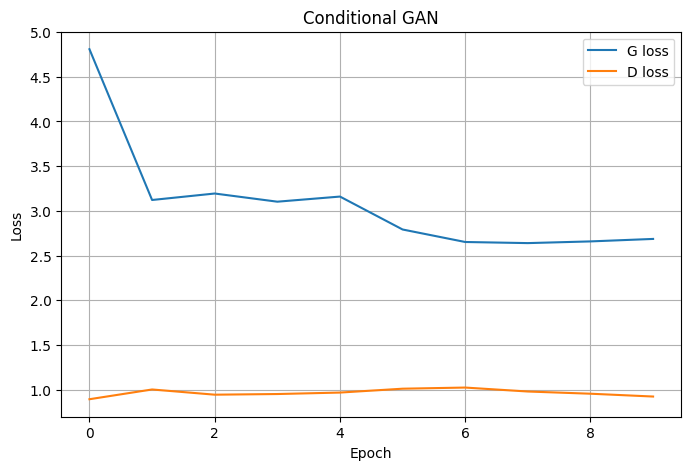

In [25]:
plot_losses(history_cgan, title="Conditional GAN")

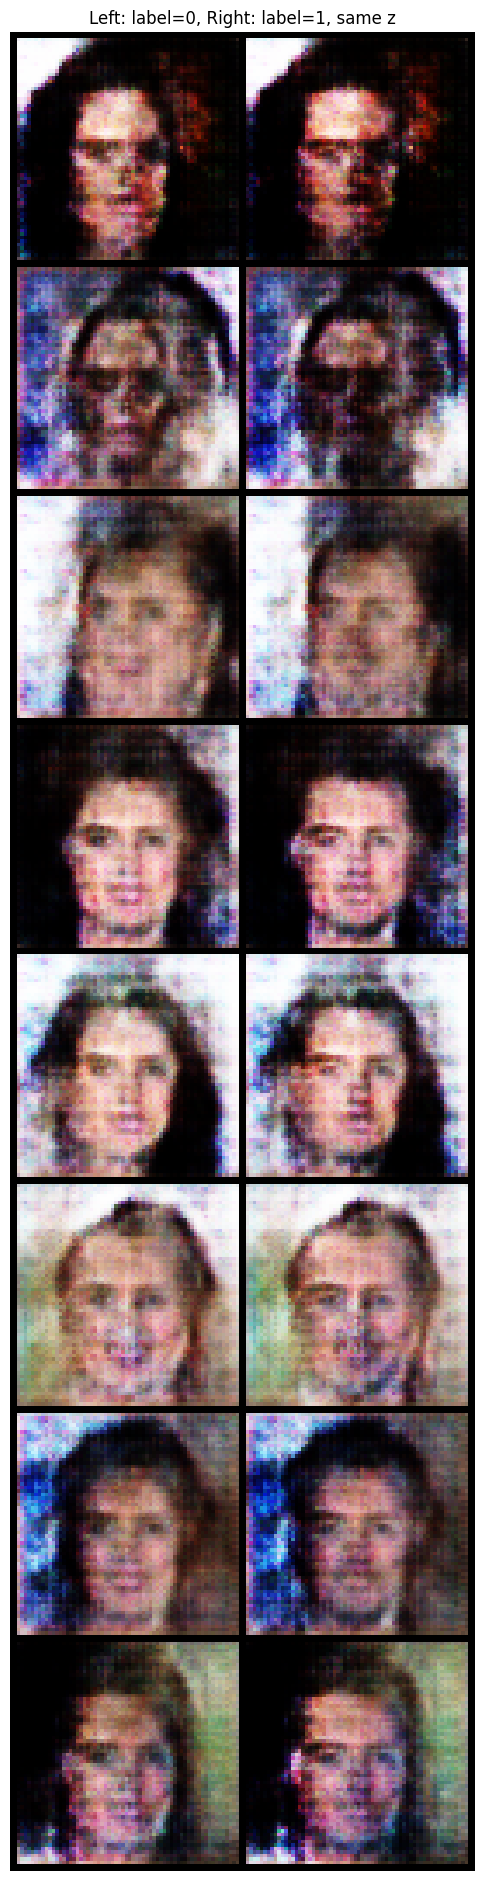

In [26]:
@torch.no_grad()
def show_same_noise_different_labels(generator, z_dim: int, n: int = 8, device: str = "cuda"):
    generator.eval()
    z = torch.randn(n, z_dim, device=device)

    y0 = torch.zeros(n, dtype=torch.long, device=device)
    y1 = torch.ones(n, dtype=torch.long, device=device)

    fake0 = generator(z, y0)
    fake1 = generator(z, y1)

    imgs = []
    for i in range(n):
        imgs.append(fake0[i].cpu())
        imgs.append(fake1[i].cpu())

    grid = utils.make_grid(denorm(torch.stack(imgs)), nrow=2, padding=2)
    plt.figure(figsize=(6, 3 * n))
    plt.imshow(_tensor_to_pil(grid))
    plt.title("Left: label=0, Right: label=1, same z")
    plt.axis("off")
    plt.show()

show_same_noise_different_labels(cG, cfg.z_dim, n=8, device=cfg.device)

In [27]:
@torch.no_grad()
def compute_fid_is_conditional(
    generator: nn.Module,
    val_loader: DataLoader,
    z_dim: int,
    device: str,
    num_images: int = 5000,
):
    generator.eval()

    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    inc = InceptionScore(normalize=False).to(device)

    real_seen = 0
    all_val_labels = []
    for _, labels in val_loader:
        all_val_labels.append(labels)
    all_val_labels = torch.cat(all_val_labels, dim=0)

    for real_imgs, _ in tqdm(val_loader, desc="FID/IS real"):
        real_imgs = real_imgs.to(device)
        real_uint8 = to_uint8_batch(real_imgs)
        fid.update(real_uint8, real=True)
        real_seen += real_imgs.size(0)
        if real_seen >= num_images:
            break

    fake_seen = 0
    batch_size = val_loader.batch_size or 64
    probs = torch.bincount(all_val_labels, minlength=2).float()
    probs = probs / probs.sum()

    while fake_seen < num_images:
        cur_bs = min(batch_size, num_images - fake_seen)
        z = torch.randn(cur_bs, z_dim, device=device)
        y = torch.multinomial(probs, num_samples=cur_bs, replacement=True).to(device)
        fake_imgs = generator(z, y)
        fake_uint8 = to_uint8_batch(fake_imgs)
        fid.update(fake_uint8, real=False)
        inc.update(fake_uint8)
        fake_seen += cur_bs

    fid_value = fid.compute().item()
    is_mean, is_std = inc.compute()
    return {
        "FID": float(fid_value),
        "IS_mean": float(is_mean.item()),
        "IS_std": float(is_std.item()),
    }

metrics_cgan = compute_fid_is_conditional(cG, val_loader, cfg.z_dim, cfg.device, cfg.eval_num_images)
metrics_cgan

FID/IS real:   0%|          | 0/16 [00:00<?, ?it/s]

{'FID': 266.63702392578125,
 'IS_mean': 2.9924161434173584,
 'IS_std': 0.13179242610931396}

## WGAN-GP (доп)

In [28]:
class WGANCritic(nn.Module):
    def __init__(self, base_channels=64, img_channels=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(img_channels, base_channels, 4, 2, 1, bias=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels, base_channels * 2, 4, 2, 1, bias=True),
            nn.InstanceNorm2d(base_channels * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1, bias=True),
            nn.InstanceNorm2d(base_channels * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels * 4, base_channels * 8, 4, 2, 1, bias=True),
            nn.InstanceNorm2d(base_channels * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(base_channels * 8, 1, 4, 1, 0, bias=True),
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [29]:
wG = Generator(z_dim=cfg.z_dim, base_channels=cfg.g_features).to(cfg.device)
wC = WGANCritic(base_channels=cfg.d_features).to(cfg.device)

wG.apply(weights_init_normal)
wC.apply(weights_init_normal)

opt_wG = torch.optim.Adam(wG.parameters(), lr=cfg.wgan_lr, betas=(cfg.wgan_beta1, cfg.wgan_beta2))
opt_wC = torch.optim.Adam(wC.parameters(), lr=cfg.wgan_lr, betas=(cfg.wgan_beta1, cfg.wgan_beta2))

fixed_noise_wgan = torch.randn(64, cfg.z_dim, device=cfg.device)

In [30]:
def gradient_penalty(critic, real, fake, device):
    batch_size = real.size(0)
    epsilon = torch.rand(batch_size, 1, 1, 1, device=device, requires_grad=True)
    interpolated = epsilon * real + (1 - epsilon) * fake
    interpolated.requires_grad_(True)

    mixed_scores = critic(interpolated)

    grad = torch.autograd.grad(
        inputs=interpolated,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    grad = grad.view(batch_size, -1)
    grad_norm = grad.norm(2, dim=1)
    gp = ((grad_norm - 1) ** 2).mean()
    return gp

In [32]:
def train_wgan_gp(
    G, C, train_loader, cfg: Config, epochs: int = 20
):
    history = {
        "g_loss": [],
        "c_loss": [],
        "wasserstein_est": [],
    }

    try:
      for epoch in range(1, epochs + 1):
        loop = tqdm(train_loader, desc=f"[WGAN-GP] Epoch {epoch}/{epochs}")
        g_running = 0.0
        c_running = 0.0
        w_running = 0.0
        g_steps = 0
        c_steps = 0

        for i, (real_imgs, _) in enumerate(loop):
            real_imgs = real_imgs.to(cfg.device)
            batch_size = real_imgs.size(0)

            for _ in range(cfg.n_critic):
                z = torch.randn(batch_size, cfg.z_dim, device=cfg.device)
                fake_imgs = G(z)

                opt_wC.zero_grad()

                critic_real = C(real_imgs)
                critic_fake = C(fake_imgs.detach())

                gp = gradient_penalty(C, real_imgs, fake_imgs.detach(), cfg.device)

                wasserstein_est = critic_real.mean() - critic_fake.mean()
                c_loss = (critic_fake.mean() - critic_real.mean()) + cfg.lambda_gp * gp

                c_loss.backward()
                opt_wC.step()

                c_running += c_loss.item()
                w_running += wasserstein_est.item()
                c_steps += 1

            z = torch.randn(batch_size, cfg.z_dim, device=cfg.device)
            fake_imgs = G(z)

            opt_wG.zero_grad()
            gen_fake = C(fake_imgs)
            g_loss = -gen_fake.mean()
            g_loss.backward()
            opt_wG.step()

            g_running += g_loss.item()
            g_steps += 1

            loop.set_postfix({
                "g_loss": f"{g_loss.item():.4f}",
                "c_loss": f"{c_loss.item():.4f}",
                "W_est": f"{wasserstein_est.item():.4f}",
            })

        history["g_loss"].append(g_running / max(g_steps, 1))
        history["c_loss"].append(c_running / max(c_steps, 1))
        history["wasserstein_est"].append(w_running / max(c_steps, 1))

        sample_path = Path(cfg.samples_dir) / f"wgan_gp_epoch_{epoch:03d}.png"
        save_generator_samples(G, fixed_noise_wgan, sample_path)

        ckpt_path = Path(cfg.checkpoints_dir) / f"wgan_gp_epoch_{epoch:03d}.pt"
        torch.save({
            "G": G.state_dict(),
            "C": C.state_dict(),
            "opt_G": opt_wG.state_dict(),
            "opt_C": opt_wC.state_dict(),
            "history": history,
            "cfg": asdict(cfg),
        }, ckpt_path)

    except KeyboardInterrupt:
        print(f"WGAN-GP interrupted after epoch {len(history['g_loss'])}")
    return history

history_wgan = train_wgan_gp(wG, wC, train_loader, cfg, epochs=6)

[WGAN-GP] Epoch 1/6:   0%|          | 0/140 [00:00<?, ?it/s]

[WGAN-GP] Epoch 2/6:   0%|          | 0/140 [00:00<?, ?it/s]

[WGAN-GP] Epoch 3/6:   0%|          | 0/140 [00:00<?, ?it/s]

[WGAN-GP] Epoch 4/6:   0%|          | 0/140 [00:00<?, ?it/s]

[WGAN-GP] Epoch 5/6:   0%|          | 0/140 [00:00<?, ?it/s]

[WGAN-GP] Epoch 6/6:   0%|          | 0/140 [00:00<?, ?it/s]

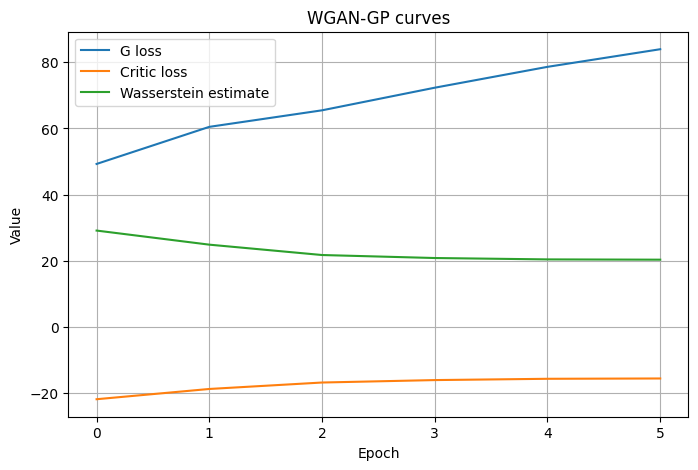

In [33]:
def plot_wgan_losses(history: dict[str, list[float]], title: str = "WGAN-GP curves"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["g_loss"], label="G loss")
    plt.plot(history["c_loss"], label="Critic loss")
    plt.plot(history["wasserstein_est"], label="Wasserstein estimate")
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_wgan_losses(history_wgan)

In [34]:
metrics_wgan = compute_fid_is_unconditional(wG, val_loader, cfg.z_dim, cfg.device, cfg.eval_num_images)
metrics_wgan

/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


FID/IS real:   0%|          | 0/16 [00:00<?, ?it/s]

{'FID': 227.48736572265625,
 'IS_mean': 2.9358203411102295,
 'IS_std': 0.11915404349565506}

In [36]:
results = []
results.append({"Model": "GAN", **metrics_gan})
results.append({"Model": "cGAN", **metrics_cgan})
results.append({"Model": "WGAN-GP", **metrics_wgan})

results_df = pd.DataFrame(results)
results_df

,Model,FID,IS_mean,IS_std
0,GAN,161.616592,2.105499,0.083291
1,cGAN,266.637024,2.992416,0.131792
2,WGAN-GP,227.487366,2.935820,0.119154
